# Step 4 — Baseline Models

Two simple models -- **popularity** and **ALS collaborative filtering** -- trained and
evaluated on the Amazon Reviews 2023 (5-core, `Video_Games`) dataset. These establish the
floor every later stage of the project (Semantic ID retrieval, the generative sequential
model, ranking) has to beat.

See `docs/00_roadmap.md` Step 4 and `docs/02_split_and_eval.md` for the full methodology
writeup. This notebook is an exploratory companion to `backend/scripts/run_baselines.py`
-- it imports the same model code so results here match the production script exactly,
rather than reimplementing the logic.

In [1]:
import os
# Must be set before numpy/implicit import -- see backend/scripts/run_baselines.py for why.
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import sys
sys.path.insert(0, os.path.abspath(os.path.join("..", "backend")))

import pandas as pd
import matplotlib.pyplot as plt

from models.popularity import PopularityRecommender
from models.als import ALSRecommender
from models.metrics import evaluate

PROCESSED_DIR = os.path.join("..", "data", "processed")
pd.set_option("display.max_colwidth", 60)

## Load data

Train/val/test come from the time-based split (`split_data.py`); `item_catalog` gives us
real product titles so we can sanity-check recommendations by eye instead of staring at
raw item IDs.

In [2]:
train = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
user_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "user_catalog.parquet"))
item_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "item_catalog.parquet"))
n_users, n_items = len(user_catalog), len(item_catalog)

def titles(item_ids):
    return item_catalog.set_index("item_id").loc[item_ids, "description"].tolist()

print(f"train: {len(train):,} interactions")
print(f"users: {n_users:,}  items: {n_items:,}")
train.head()

train: 645,982 interactions
users: 94,762  items: 25,612


,user_id,item_id,invoice_id,quantity,unit_price,timestamp
0,0,20235,r197565,1,NaN,2019-07-16 23:36:57.391
5,1,9105,r387770,1,85.00,2012-11-08 07:23:09.000
6,1,7239,r387771,1,12.53,2013-01-08 21:13:54.000
7,1,10383,r387772,1,NaN,2013-01-15 20:38:24.000
8,1,8822,r387773,1,NaN,2014-08-25 19:30:53.000


## Model 1: Popularity

Count interactions per item in train, rank, recommend the same list to everyone minus
whatever that user already has. No personalization -- see `backend/models/popularity.py`.

In [3]:
pop_model = PopularityRecommender().fit(train)

sample_user = train["user_id"].value_counts().index[50]  # a moderately active user, not an outlier
history = sorted(pop_model.user_seen[sample_user])[:5]
print(f"user {sample_user}'s history (sample of {len(pop_model.user_seen[sample_user])} items):")
for t in titles(history):
    print(" -", t)

print(f"\npopularity's top-5 recommendation for user {sample_user}:")
for t in titles(pop_model.recommend(sample_user, 5)):
    print(" -", t)

user 91321's history (sample of 105 items):
 - Alan Wake - Xbox 360
 - Terminator 3 Redemption - PlayStation 2
 - Crackdown 2 - Xbox 360
 - Metal Gear Solid Peace Walker
 - Nintendo 3DS - Cosmo Black

popularity's top-5 recommendation for user 91321:
 - amFilm Tempered Glass Screen Protector for Nintendo Switch 2017 (2-Pack)
 - Skyrim VR - PlayStation 4
 - PlayStation 4 500GB Console [Old Model][Discontinued]
 - Fallout 4 - Xbox One
 - PlayStation Plus: 12 Month Membership [Digital Code]


## Model 2: ALS (collaborative filtering)

Confidence-weighted implicit-feedback matrix factorization (`implicit` library, Hu/Koren/
Volinsky 2008 formulation) -- see `backend/models/als.py` and the diagrams/derivation
earlier in this project's build log for the math.

In [4]:
als_model = ALSRecommender(factors=64, regularization=0.05, iterations=15, alpha=40.0).fit(
    train, n_users, n_items
)

print(f"ALS top-5 recommendation for the same user {sample_user}:")
for t in titles(als_model.recommend(sample_user, 5)):
    print(" -", t)

print(f"\nis a never-before-seen user cold for ALS? {als_model.is_cold(n_users - 1)}")

ALS top-5 recommendation for the same user 91321:
 - The Evil Within - Xbox One
 - Paper Mario: Sticker Star
 - Super Smash Bros. - Nintendo Wii U
 - Far Cry 4 - PS3 [Digital Code]
 - Dishonored - PlayStation 3 Game of the Year Edition

is a never-before-seen user cold for ALS? False


## Evaluating both models

Same protocol for both: take each val/test user's train history, generate top-K
recommendations (excluding items already seen), compare against what they actually
interacted with in the held-out window. ALS falls back to popularity for cold-start users
(no train interactions) -- it has no learned vector for them at all.

In [5]:
def load_targets(path):
    df = pd.read_parquet(path)
    return {row.user_id: set(row.item_ids) for row in df.itertuples()}

val_targets = load_targets(os.path.join(PROCESSED_DIR, "val_targets.parquet"))
test_targets = load_targets(os.path.join(PROCESSED_DIR, "test_targets.parquet"))

def als_with_fallback(user_id, k):
    if als_model.is_cold(user_id):
        return pop_model.recommend(user_id, k)
    return als_model.recommend(user_id, k)

K_VALUES = (10, 20)
results = {}
for split_name, targets in [("val", val_targets), ("test", test_targets)]:
    results[split_name] = {
        "popularity": evaluate(pop_model.recommend, targets, K_VALUES),
        "als": evaluate(als_with_fallback, targets, K_VALUES),
    }

In [6]:
rows = []
for split_name, models in results.items():
    for model_name, metrics in models.items():
        rows.append({"split": split_name, "model": model_name, **metrics})
results_df = pd.DataFrame(rows).set_index(["split", "model"])
results_df.round(4)

recall@10  recall@20  ndcg@10  ndcg@20
split model                                             
val   popularity     0.0146     0.0180   0.0111   0.0122
      als            0.0149     0.0227   0.0107   0.0132
test  popularity     0.0058     0.0071   0.0038   0.0042
      als            0.0051     0.0078   0.0036   0.0044

## Visualizing the comparison

Same story either way you look at it: ALS is only marginally different from popularity,
not a clean win. Worth looking at directly rather than just the table.

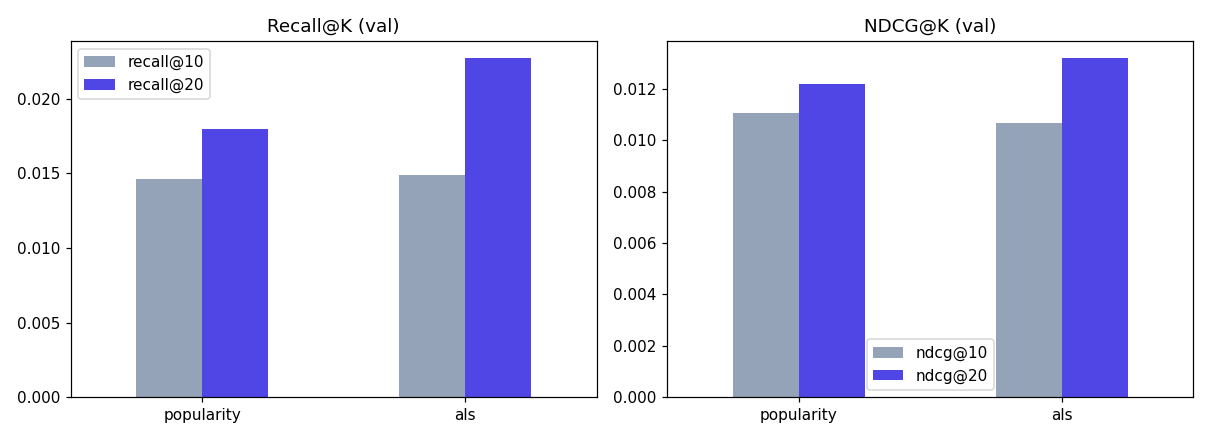

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
val_df = results_df.loc["val"]

val_df[["recall@10", "recall@20"]].plot.bar(ax=axes[0], color=["#94A3B8", "#4F46E5"])
axes[0].set_title("Recall@K (val)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

val_df[["ndcg@10", "ndcg@20"]].plot.bar(ax=axes[1], color=["#94A3B8", "#4F46E5"])
axes[1].set_title("NDCG@K (val)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "baseline_comparison.png"), dpi=110)
plt.show()

## Interpretation

ALS does **not** cleanly beat popularity here. It's ahead on recall@20 in both splits,
roughly tied on recall@10, and slightly *behind* popularity on test recall@10 and both
ndcg@10 numbers.

This is a genuine, honest finding worth reporting rather than a bug to explain away:

- **Very sparse data.** Median 6 interactions per user across 25,612 items leaves little
  signal for ALS to personalize against.
- **Heavy cold-start.** 18-28% of val/test users were never seen in train (see
  `docs/02_split_and_eval.md`). ALS has no learned vector for these users at all, so it
  falls back to popularity -- meaning a meaningful chunk of "ALS's" reported score is
  really popularity's score, just relabeled.

This result is exactly the argument for not stopping here. It's the direct, measured
motivation for Step 5 (RQ-VAE Semantic IDs) and Step 6 (generative sequential retrieval):
both are specifically designed to produce usable recommendations for sparse and cold-start
users/items, which is precisely where this baseline comparison shows collaborative
filtering alone falling short.